In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import sys
import astropy
from matplotlib.lines import Line2D
from tqdm.notebook import tqdm
from scipy.stats import norm

In [5]:
sys.path.append('/home/masson/afterglowpy/orphan_modules')
from plotting_lc import plot_pseudo_obs
from tools import galactic_extinction

In [6]:
from dustmaps.sfd import SFDQuery
from dustmaps.csfd import CSFDQuery
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

In [7]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [8]:
sfd = SFDQuery()
csfd = CSFDQuery()

# Test

In [9]:
c = SkyCoord('07h00m00.00000s', '+00d00m00.0000s', frame='icrs')
ebv = csfd(c)

In [10]:
print('E(B-V) = {:.3f} mag'.format(ebv))

E(B-V) = 0.632 mag


For an extinction factor $R_V = 3.1$, $A_b/E(B-V)_{SFD}$ is: 
- LSST u: 4.145
- LSST g: 3.237
- LSST r: 2.273
- LSST i: 1.684
- LSST z: 1.323
- LSST y: 1.088

In [11]:
df = pd.read_csv('/home/masson/Documents/galactic_extinction/schlafly_dust_factor.csv', delimiter=',', skiprows=1)
df_lsst = df[(df.Bandpass == 'LSST_u') 
   | (df.Bandpass == 'LSST_g')
   | (df.Bandpass == 'LSST_r')
   | (df.Bandpass == 'LSST_i')
   | (df.Bandpass == 'LSST_z')
   | (df.Bandpass == 'LSST_y')]
df_lsst

,Bandpass,lambda_eff,R_V21,R_V31,R_V41,R_V51
38,LSST_u,3693.2,5.243,4.145,3.652,3.373
39,LSST_g,4797.3,3.739,3.237,3.006,2.872
40,LSST_r,6195.8,2.245,2.273,2.286,2.294
41,LSST_i,7515.3,1.571,1.684,1.737,1.767
42,LSST_z,8664.4,1.259,1.323,1.353,1.370
43,LSST_y,9710.3,1.075,1.088,1.094,1.098


# Galactic extinction in r-band depending on the GRB coordinates

In [15]:
orphans = pd.read_pickle('../data/orphans_pseudo_obs_5pts_low_redshift.pkl')

In [16]:
df_orphans = pd.DataFrame(data=orphans)
df_orphans

,config,grb_time,grb_coord,time,mags,filt,mags_lim,mags_err
0,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2028-01-27T21:02:31.349,07h26m11.01459973s -70d07m52.24853447s,"[61799.0624184236, 61799.08581496566, 61799.11...","[21.246134716832007, 20.924015405211563, 20.94...","[b, g, g, orange, c, g, m, m, orange, r, g, or...","[23.881127647319328, 24.22190413717712, 24.357...","[0.023906327654324492, 0.012511731806851119, 0..."
1,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2027-01-23T22:00:36.407,12h13m45.46319506s -09d06m27.83960224s,"[61434.31270925278, 61434.33756975828, 61434.3...","[20.68158597927758, 20.51677030056701, 20.5213...","[orange, r, r, m, orange, r, g, orange, g, ora...","[22.52567019213692, 22.418285587499362, 22.303...","[0.03960308166701617, 0.037726450905223266, 0...."
2,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2030-06-10T21:00:53.195,20h45m11.86794444s -39d42m53.84417427s,"[62672.36971634495, 62672.39259719335, 62676.3...","[22.21214626764265, 22.21464790106282, 22.8715...","[m, m, g, orange, b, g, b, g, orange, r, g, b,...","[22.02215727467307, 22.109829497340613, 23.639...","[0.2319734790072924, 0.21614160241887925, 0.10..."
3,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2029-11-18T15:33:08.925,06h16m59.64207199s -69d14m54.89699607s,"[62460.27243120574, 62460.295834457014, 62461....","[25.89021611514251, 25.82889182147147, 24.2200...","[m, m, m, m, orange, r, g, orange, r, g, orang...","[21.747367341144084, 21.801072556402104, 22.00...","[2.5066764517918005, 2.4035374366198927, 1.009..."
4,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2026-04-15T15:09:17.377,08h43m16.60457779s -06d42m12.11817244s,"[61145.9763374639, 61145.987157520074, 61153.0...","[19.469103260513663, 19.232515638924344, 20.14...","[orange, r, m, m, m, r, m, g, orange, orange, ...","[22.598679532392353, 22.22972024128991, 21.689...","[0.013393499944544678, 0.014854757325847371, 0..."
...,...,...,...,...,...,...,...,...
2597,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2025-11-16T20:34:01.853,07h05m39.19825507s -52d17m01.51804425s,"[60999.25174777294, 60999.27617251186, 61001.3...","[22.790716403483543, 22.658997620661246, 22.83...","[g, orange, r, orange, m, m, orange, r, m, m, ...","[24.646149327010697, 24.092376591245774, 23.08...","[0.04034889247986917, 0.05770465661096166, 0.1..."
2598,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2029-09-29T00:16:29.722,01h34m38.91035433s -25d51m16.84686321s,"[62408.29392573449, 62408.31792500259, 62412.3...","[15.56949165048975, 15.500115079933455, 19.092...","[orange, r, g, g, orange, g, orange, r, c, g, ...","[23.108831931421122, 22.93020138903655, 23.553...","[0.005028507928688408, 0.005037811316339086, 0..."
2599,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2031-02-21T08:44:22.153,19h56m06.82339552s -15d06m21.22110677s,"[62928.390098706, 62928.39324078432, 62928.396...","[21.115355520025325, 21.116175016174175, 21.11...","[orange, orange, orange, orange, g, g, m, m, r...","[22.007053803780213, 22.028744174767173, 22.03...","[0.09211225403510366, 0.09045784786058612, 0.0..."
2600,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2029-11-12T20:59:12.565,03h05m11.20968615s -56d11m25.68291619s,"[62453.15562317168, 62454.092361884395, 62454....","[26.604246660313194, 21.759276898974644, 21.82...","[orange, r, orange, orange, r, r, m, m, orange...","[23.503257988452244, 22.903159475953885, 23.48...","[1.624847831312058, 0.07378166735863417, 0.047..."


/home/masson/anaconda3/envs/afterglowpy/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/masson/anaconda3/envs/afterglowpy/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


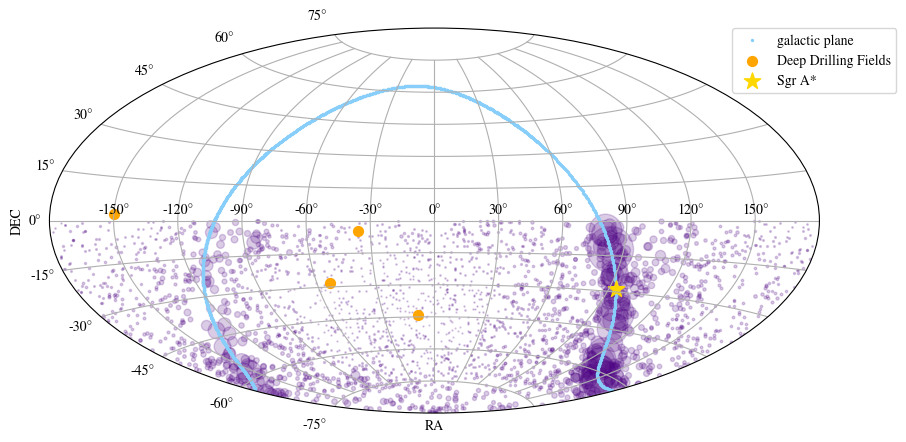

In [18]:
plt.figure(figsize=(10,5))
ax = plt.subplot(111, projection="aitoff")

for config, coord in zip(df_orphans['config'], df_orphans['grb_coord']):
    
    c = SkyCoord(coord)
    ra = -c.ra.wrap_at(180 * u.deg).radian
    dec = c.dec.rad
    
    ebv = sfd(c)
    a_lambda_r = ebv * df_lsst.R_V31[40]
    size = a_lambda_r * 20

    ax.scatter(ra, dec, c='indigo', alpha=0.2, s=size)
    

# plot galactic plane
disk = [np.linspace(-5, 5,1000), [0]*1000]
ll = disk[0]
bb = disk[1]
c_gal = SkyCoord(l=ll*u.rad, b=bb*u.radian, frame='galactic')
c_gal_icrs = c_gal.icrs
ax.scatter(-c_gal_icrs.ra.wrap_at(180 * u.deg).radian, c_gal_icrs.dec.radian, c='lightskyblue', s=2, label='galactic plane')

# (ra, dec) coordinates of Rubin LSST Deep Drilling Fields
c_elais = SkyCoord('00h37m48s -44d00m00s', frame='icrs')
c_xmm_lss = SkyCoord('02h22m50s -04d45m00s', frame='icrs')
c_chandra = SkyCoord('03h32m30s -28d06m00s', frame='icrs')
c_cosmos = SkyCoord('10h00m24s +02d10m55s', frame='icrs')

ra_ddf = [-c_elais.ra.wrap_at(180 * u.deg).radian, 
      -c_xmm_lss.ra.wrap_at(180 * u.deg).radian,
      -c_chandra.ra.wrap_at(180 * u.deg).radian,
      -c_cosmos.ra.wrap_at(180 * u.deg).radian]

dec_ddf = [c_elais.dec.rad,
       c_xmm_lss.dec.rad,
       c_chandra.dec.rad,
       c_cosmos.dec.rad]

ax.scatter(ra_ddf, dec_ddf, c='orange', s=50, label='Deep Drilling Fields')

# (ra, dec) coordinates of Sgr A*
c_sgr_a = SkyCoord('17h45m40s -29d0m28s', frame='icrs')
ax.scatter(-c_sgr_a.ra.wrap_at(180 * u.deg).radian, c_sgr_a.dec.rad, c='gold', marker='*', s=150, label='Sgr A*')   

#plt.title('Galactic extinction')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(bbox_to_anchor=(1.1,1.), borderaxespad=0)
plt.grid(True)

# Impact of galactic extinction on the afterglow light curve

In [19]:
oa = df_orphans.iloc[48]

In [20]:
coord = oa['grb_coord']
c = SkyCoord(coord)

In [21]:
ebv = csfd(c)

In [22]:
a_lambda_u = ebv*df_lsst.R_V31[38]
print('A_u = {:.3f} mag'.format(a_lambda_u))

A_u = 0.298 mag


In [23]:
a_lambda_g = ebv*df_lsst.R_V31[39]
print('A_g = {:.3f} mag'.format(a_lambda_g))

A_g = 0.233 mag


In [24]:
a_lambda_r = ebv*df_lsst.R_V31[40]
print('A_r = {:.3f} mag'.format(a_lambda_r))

A_r = 0.163 mag


In [25]:
a_lambda_i = ebv*df_lsst.R_V31[41]
print('A_i = {:.3f} mag'.format(a_lambda_i))

A_i = 0.121 mag


In [26]:
a_lambda_z = ebv*df_lsst.R_V31[42]
print('A_z = {:.3f} mag'.format(a_lambda_z))

A_z = 0.095 mag


In [27]:
a_lambda_y = ebv*df_lsst.R_V31[43]
print('A_y = {:.3f} mag'.format(a_lambda_y))

A_y = 0.078 mag


In [28]:
ebv_c = csfd(c)
a_lambda_u_c = ebv_c*df_lsst.R_V31[38]
a_lambda_g_c = ebv_c*df_lsst.R_V31[39]
a_lambda_r_c = ebv_c*df_lsst.R_V31[40]
a_lambda_i_c = ebv_c*df_lsst.R_V31[41]
a_lambda_z_c = ebv_c*df_lsst.R_V31[42]
a_lambda_y_c = ebv_c*df_lsst.R_V31[43]

In [29]:
mags = oa['mags']
filt = oa['filt']

true_mags = []
true_mags_c = []

for i in range(len(mags)):
    if filt[i] == 'b':
        true_mags.append(mags[i] + a_lambda_u)
        true_mags_c.append(mags[i] + a_lambda_u_c)
    elif filt[i] == 'c':
        true_mags.append(mags[i] + a_lambda_g)
        true_mags_c.append(mags[i] + a_lambda_g_c)
    elif filt[i] == 'g':
        true_mags.append(mags[i] + a_lambda_r)
        true_mags_c.append(mags[i] + a_lambda_r_c)
    elif filt[i] == 'orange':
        true_mags.append(mags[i] + a_lambda_i)
        true_mags_c.append(mags[i] + a_lambda_i_c)
    elif filt[i] == 'r':
        true_mags.append(mags[i] + a_lambda_z)
        true_mags_c.append(mags[i] + a_lambda_z_c)
    else:
        true_mags.append(mags[i] + a_lambda_y)
        true_mags_c.append(mags[i] + a_lambda_y_c)

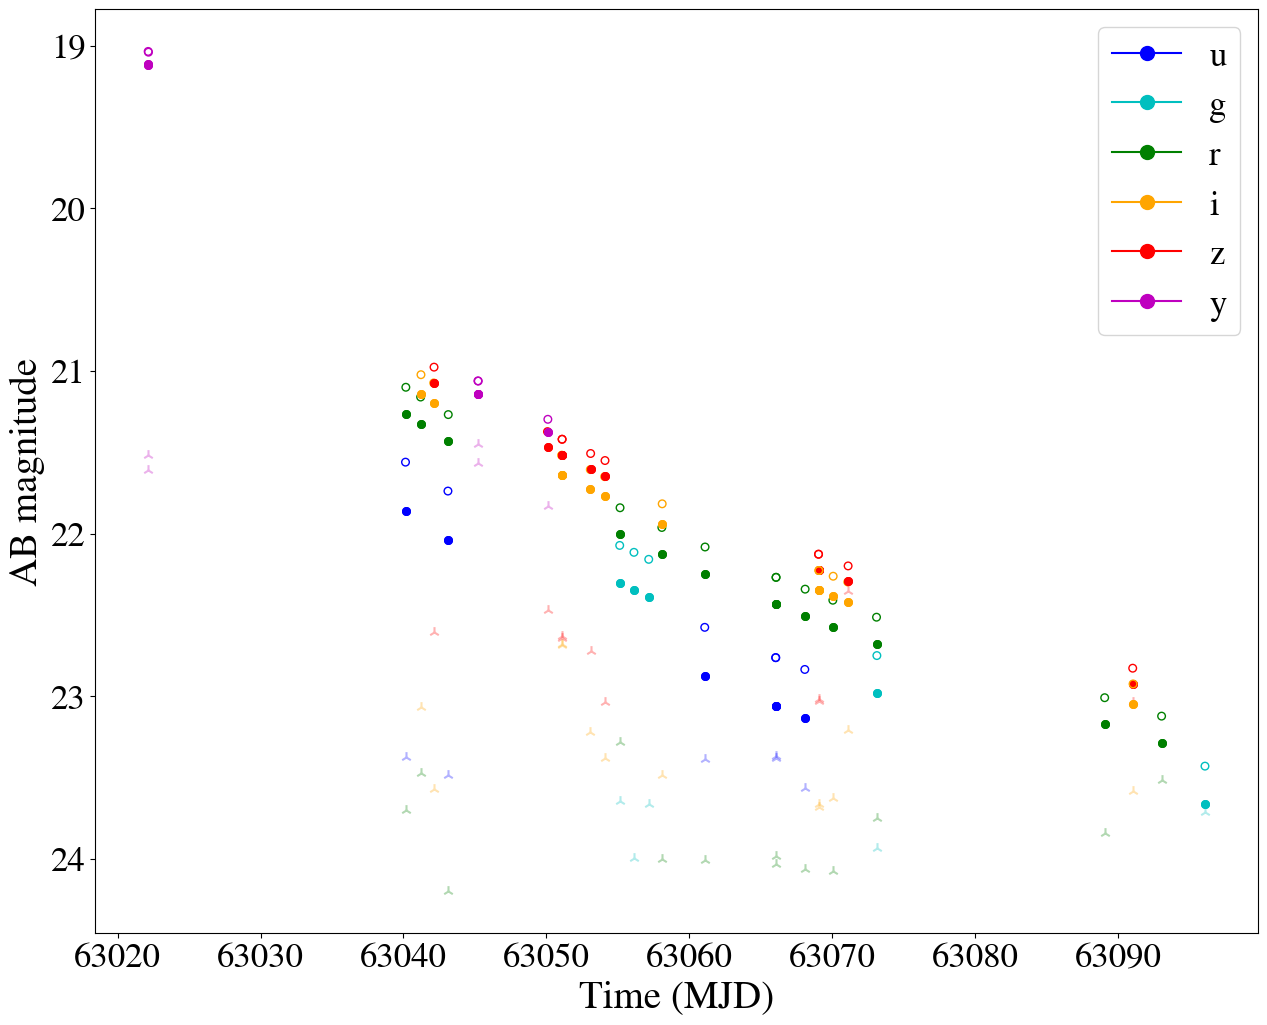

In [30]:
# test with and without extinction

plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(15,12))

filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
filtercolors = {'u':'b', 'g':'c', 'r':'g', 'i':'orange', 'z':'r', 'y':'m'}

x_times = oa['time']
z_colors = oa['filt']
y_true_mags = true_mags
y_true_mags_c = true_mags_c
y_mags = oa['mags']
mags_lim = oa['mags_lim']
plt.gca().invert_yaxis()
plt.ylabel('AB magnitude', fontsize=28)
        

# plot pseudo observed light curve
for x, y, y_t, y_t_c, z, m in zip(x_times, y_mags, y_true_mags, y_true_mags_c, z_colors, mags_lim):
    if y_t<m and y_t_c<m:
        plt.scatter(x, y_t_c, c=z, s=30, label='with extinction (CSFD)')
        plt.scatter(x, y_t, c=z, s=30, label='with extinction (SFD)')
        plt.scatter(x, y, s=30, facecolors='none', edgecolors=z, label='without extinction')
        plt.scatter(x, m, c=z, marker='2', s=60, alpha=0.3)

    
#plt.title('Pseudo observed light curve', fontsize=28)
plt.xlabel('Time (MJD)', fontsize=28)
    
legend_elements_2 = list()
        
for filt in filterlist:
    fcolor = filtercolors[filt]
    legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                            markerfacecolor=fcolor, markersize=10))
plt.legend(handles=legend_elements_2)
#plt.savefig('/home/masson/afterglowpy/figures/extincted_light_curve.pdf', transparent=True, bbox_inches='tight')
plt.show()